In [50]:
!git clone https://github.com/NVlabs/CuTe.git

fatal: destination path 'CuTe' already exists and is not an empty directory.


In [51]:
%cd CuTe

/content/CuTe/CuTe


In [53]:
!pip install -e ".[viz]"

Obtaining file:///content/CuTe/CuTe
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for pycute (pyproject.toml) ... done
  Created wheel for pycute: filename=pycute-0.1.0-0.editable-py3-none-any.whl size=11903 sha256=c420f51a1e059f2c684a093e1d92be6df4491343f1a1ceb6e6ad3a499761248a
  Stored in directory: /tmp/pip-ephem-wheel-cache-est3nabl/wheels/b5/d7/d8/897bda68761a9d8dee5aeda3851e18b26f88a850115c6570c1
Successfully built pycute
  Attempting uninstall: pycute
    Found existing installation: pycute 0.1.0
    Uninstalling pycute-0.1.0:
      Successfully uninstalled pycute-0.1.0


### pycute helpers

In [54]:
#https://github.com/NVlabs/CuTe/blob/111253d17e2f0f8631f43999b43ac4afa5954b04/examples/algorithms/gemm.ipynb
import contextlib
import ctypes
import importlib.util
import inspect
import io
import itertools
import sys
import tempfile
from pathlib import Path

from IPython.display import SVG, display
from pycute import *
from pycute.alg.ref import gemm
from pycute.util import draw_svg, print_tensor

HAS_SVG = importlib.util.find_spec("svgwrite") is not None
if not HAS_SVG:
    print("svgwrite not installed; layout figures skipped. pip install -e '.[viz]'")
from pycute.util.draw_colors import index_grey_8x

_SVG_DIR = Path(tempfile.mkdtemp(prefix="pycute-gemm-"))
_SVG_COUNT = itertools.count()

def show(t, name=None, color=index_grey_8x):
    """
    Draw a Layout or Tensor, labelled `name`, falling back to a table when it
    cannot be drawn: `draw_svg` handles rank 1 and 2 only, writes a file rather
    than returning one, and a layout on basis strides maps to coordinates, which
    have no address to color.
    """
    layout = t.layout if isinstance(t, Tensor) else t
    if name is not None:
        print(f"{name}: {layout}")
    if HAS_SVG and rank(t) in (1, 2) and isinstance(layout(0), int):
        path = _SVG_DIR / f"layout{next(_SVG_COUNT)}.svg"
        with contextlib.redirect_stdout(io.StringIO()):
            draw_svg(t, filename=str(path), color=color)
        display(SVG(str(path)))
    else:
        print_tensor(t, print_type=False)

## topk co-design notes

In [72]:
import array
CTA = Tensor(Ptr(array.array('i', range(256))), Layout((8, 4, 8), (1, 8, 32)))

In [73]:
show(CTA)

0     8     16    24    
1     9     17    25    
2     10    18    26    
3     11    19    27    
4     12    20    28    
5     13    21    29    
6     14    22    30    
7     15    23    31    
----------  k = 1  --------------
32    40    48    56    
33    41    49    57    
34    42    50    58    
35    43    51    59    
36    44    52    60    
37    45    53    61    
38    46    54    62    
39    47    55    63    
----------  k = 2  --------------
64    72    80    88    
65    73    81    89    
66    74    82    90    
67    75    83    91    
68    76    84    92    
69    77    85    93    
70    78    86    94    
71    79    87    95    
----------  k = 3  --------------
96    104   112   120   
97    105   113   121   
98    106   114   122   
99    107   115   123   
100   108   116   124   
101   109   117   125   
102   110   118   126   
103   111   119   127   
----------  k = 4  --------------
128   136   144   152   
129   137   145   153   
130   138   14

topk warp shfl xor

XOR 16: top = destination lane, bottom = source lane
Saved as /tmp/lanes.svg


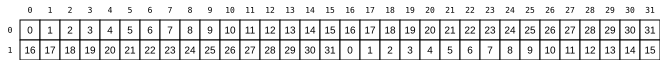

XOR 8: top = destination lane, bottom = source lane
Saved as /tmp/lanes.svg


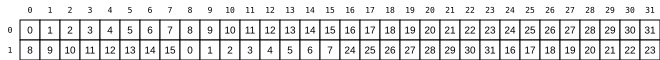

XOR 4: top = destination lane, bottom = source lane
Saved as /tmp/lanes.svg


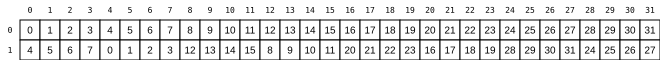

XOR 2: top = destination lane, bottom = source lane
Saved as /tmp/lanes.svg


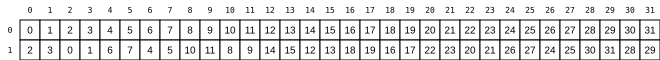

XOR 1: top = destination lane, bottom = source lane
Saved as /tmp/lanes.svg


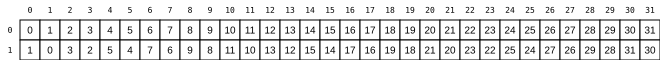

In [104]:
import array
from pycute import *
from pycute.util import draw_svg
from IPython.display import SVG, display

lanes = Tensor(Ptr(array.array('i', range(32))), Layout(32))

for j in (16, 8, 4, 2, 1):
    P = Layout((2, 32), (F2(j), F2(1)))
    print(f"XOR {j}: top = destination lane, bottom = source lane")
    draw_svg(composition(lanes, P), "/tmp/lanes.svg")
    display(SVG(filename="/tmp/lanes.svg"))

maybe better to rmem->smem local_topk $\forall$ lanes

current topk.cu ~122 reg / thread $\rightarrow$ 2 CTA / SM (CTA=256)

CTA = 512 (256, 256, +smem) to expand previous design and distribute work

2 CTA / SM

In [ ]:
note add_bf16x2, rcp_bf16x2 (a python script can generate these)